# Heavy tails in repository popularity

Star counts are generated as Poisson draws around a Pareto-distributed
latent popularity, so they have a power-law tail with a known exponent. We
fit it following Clauset, Shalizi & Newman (2009) and ask whether a
lognormal fits just as well.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pcc_vizforge.plots.style import apply_matplotlib_style

apply_matplotlib_style()
SEED = 20240101

In [2]:
from pcc_vizforge.generators import GitHubGenerator
from pcc_vizforge.analysis import heavy_tails

gen = GitHubGenerator(n_repositories=8000, popularity_exponent=2.2)
repos = gen.generate(seed=SEED)
stars = repos["stars"].to_numpy()
print(f"Gini of stars: {heavy_tails.gini(stars):.3f}; median {np.median(stars):.0f}, max {stars.max():,}")

Gini of stars: 0.703; median 8, max 6,541


PowerLawFit(alpha=2.2103848876500307, alpha_stderr=0.021167781851520736, xmin=10.0, ks_distance=0.007782713849721956, n_tail=3274, n_total=7886, discrete=True)


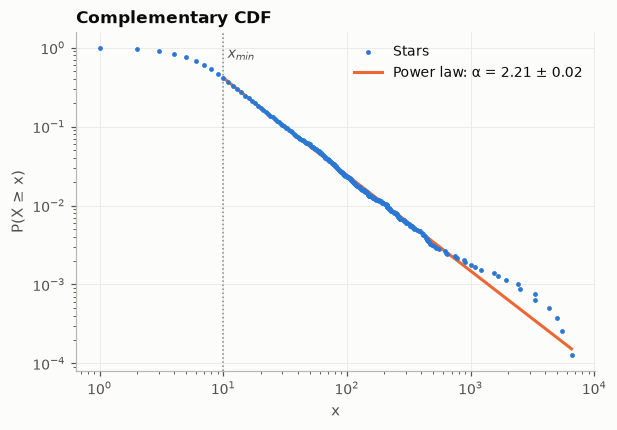

In [3]:
from pcc_vizforge.plots import diagnostics as D

pos = stars[stars > 0]
fit = heavy_tails.fit_power_law(pos, discrete=True, min_tail=400)
print(fit)
D.ccdf_figure(pos, fit, label="Stars");

## Is a power law plausible? (bootstrap GOF)

A p-value above 0.1 means the power law cannot be rejected.

In [4]:
gof = heavy_tails.power_law_gof(pos, fit, n_bootstrap=100, seed=SEED)
gof.p_value, gof.details["plausible"]

(0.75, True)

## Power law vs. alternatives (Vuong test)

A positive statistic favours the power law. A large p-value means the data can't distinguish the two models; this is common for lognormal vs. power law in finite samples.

In [5]:
pd.DataFrame([heavy_tails.compare_distributions(pos, fit, alt).to_dict() | {"alternative": alt}
              for alt in ("lognormal", "exponential")])[["alternative", "statistic", "p_value", "details"]]

,alternative,statistic,p_value,details
0,lognormal,0.751033,4.526326e-01,"{'log_likelihood_ratio': 1.1016554719940346, '..."
1,exponential,7.234619,4.668377e-13,"{'log_likelihood_ratio': 2299.461709152156, 'f..."


## Exponent recovery across settings

In [6]:
rows = []
for alpha in (1.8, 2.2, 2.6):
    s = GitHubGenerator(n_repositories=8000, popularity_exponent=alpha).calculate_statistics(
        GitHubGenerator(n_repositories=8000, popularity_exponent=alpha).generate(seed=SEED))
    rows.append({"true α": alpha, "α̂": s["power_law"]["alpha"], "SE": s["power_law"]["alpha_stderr"], "x_min": s["power_law"]["xmin"]})
pd.DataFrame(rows).round(3)

,true α,α̂,SE,x_min
0,1.8,1.800,0.012,10.0
1,2.2,2.210,0.021,10.0
2,2.6,2.636,0.032,10.0
